## Part_1 
......Data Loading

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
df = pd.read_csv('sales_data_db.csv')

In [22]:
df.head()

,Order_ID,Date,Product,Category,City,Quantity,Price,Revenue,Month
0,1001,2025-02-19,Printer,Electronics,Kolkata,3.0,9591,28773.0,2
1,1002,2025-08-08,Pen,Stationery,Hyderabad,5.0,318,1590.0,8
2,1003,2025-07-28,Mouse,Electronics,Chennai,1.0,697,697.0,7
3,1004,2025-08-15,Chair,Furniture,Ahmedabad,1.0,3410,3410.0,8
4,1005,2025-04-12,Mouse,Electronics,Mumbai,3.0,624,1872.0,4


In [23]:
df.tail()

,Order_ID,Date,Product,Category,City,Quantity,Price,Revenue,Month
1995,2996,2025-12-26,Sofa,Furniture,Ahmedabad,4.0,15124,60496.0,12
1996,2997,2025-02-27,Notebook,Stationery,Ahmedabad,3.0,160,480.0,2
1997,2998,2025-04-25,Chair,Furniture,Delhi,3.0,3590,10770.0,4
1998,2999,2025-10-18,Monitor,Electronics,Mumbai,2.0,8550,17100.0,10
1999,3000,2025-05-29,Bag,Accessories,Kolkata,5.0,1220,6100.0,5


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Order_ID  2000 non-null   int64  
 1   Date      2000 non-null   str    
 2   Product   2000 non-null   str    
 3   Category  2000 non-null   str    
 4   City      2000 non-null   str    
 5   Quantity  2000 non-null   float64
 6   Price     2000 non-null   int64  
 7   Revenue   2000 non-null   float64
 8   Month     2000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 140.8 KB


## Part_2
.....Data Cleaning

##### Check missing values

In [67]:
print("\nMissing values per column:")
df.isnull().sum()


Missing values per column:


Order_ID    0
Date        0
Product     0
Category    0
City        0
Quantity    0
Price       0
Revenue     0
Month       0
dtype: int64

##### Remove duplicate records

In [76]:

df = df.drop_duplicates()


##### Correct spelling mistakes if any

In [75]:

df['Category'] = df['Category'].replace({'Electroniks': 'Electronics'})
   

##### Convert Date column into datetime format

In [ ]:

df['Date'] = pd.to_datetime(df['Date'])
print("Successfully converted 'Date' column to datetime objects.")


Successfully converted 'Date' column to datetime objects.


### Part_3
.....Data Processing

##### Revenue = Quantity × Price

In [80]:
df['Revenue'] = df['Quantity'] * df['Price']

print(df.head())

   Order_ID       Date  Product     Category       City  Quantity  Price  \
0      1001 2025-02-19  Printer  Electronics    Kolkata       3.0   9591   
1      1002 2025-08-08      Pen   Stationery  Hyderabad       5.0    318   
2      1003 2025-07-28    Mouse  Electronics    Chennai       1.0    697   
3      1004 2025-08-15    Chair    Furniture  Ahmedabad       1.0   3410   
4      1005 2025-04-12    Mouse  Electronics     Mumbai       3.0    624   

   Revenue  Month  
0  28773.0      2  
1   1590.0      8  
2    697.0      7  
3   3410.0      8  
4   1872.0      4  


### Part_4 
.....Data Analysis

##### Total Revenue

In [84]:
total_revenue = df['Revenue'].sum()
print(f"Task 1 -> Total Sales Revenue: ${total_revenue:,.2f}")

Task 1 -> Total Sales Revenue: $51,501,934.00


##### Best Selling Product

In [89]:
product_quantities = df.groupby('Product')['Quantity'].sum()
best_selling_product = product_quantities.idxmax()
highest_quantity = product_quantities.max()
print(f"Task 2 -> Best Selling Product: {best_selling_product} ({highest_quantity} units sold)")

Task 2 -> Best Selling Product: Chair (568.0 units sold)


##### Best Performing City

In [90]:
revenue_by_city = df.groupby('City')['Revenue'].sum()
best_performing_city = revenue_by_city.idxmax()
highest_city_revenue = revenue_by_city.max()
print(f"Task 3 -> Best Performing City: {best_performing_city} (${highest_city_revenue:,.2f})")

Task 3 -> Best Performing City: Ahmedabad ($7,449,911.00)


##### Category Analysis

In [93]:
category_contribution = df.groupby('Category')['Revenue'].sum()
print("\nTask 4 -> Revenue Generated by Each Category:")
print(category_contribution.to_string())


Task 4 -> Revenue Generated by Each Category:
Category
Accessories      905769.0
Electronics    37095222.0
Furniture      13343784.0
Stationery       157159.0


##### Monthly Sales Analysis

In [94]:
df['Month'] = df['Date'].dt.to_period('M')
monthly_sales_trend = df.groupby('Month')['Revenue'].sum()
print("\nTask 5 -> Total Revenue Generated Per Month:")
print(monthly_sales_trend.to_string())


Task 5 -> Total Revenue Generated Per Month:
Month
2025-01    4021909.0
2025-02    3655339.0
2025-03    4607846.0
2025-04    4785474.0
2025-05    4884091.0
2025-06    3654206.0
2025-07    3979183.0
2025-08    4012286.0
2025-09    4318017.0
2025-10    4428577.0
2025-11    4185989.0
2025-12    4891185.0
2026-01      77832.0
Freq: M


### Part_5
.....Data Visualization

##### ...Bar Chart

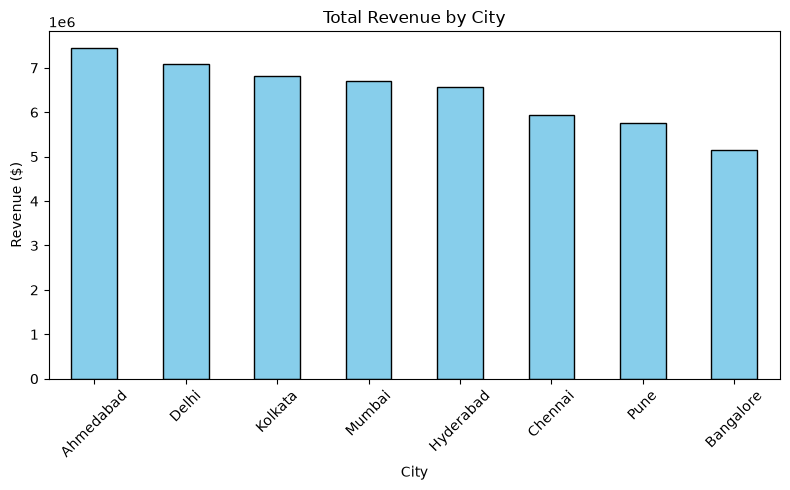

In [95]:

plt.figure(figsize=(8, 5))
revenue_by_city_sorted = revenue_by_city.sort_values(ascending=False)
revenue_by_city_sorted.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Total Revenue by City')
plt.xlabel('City')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### ...Pie Chart 

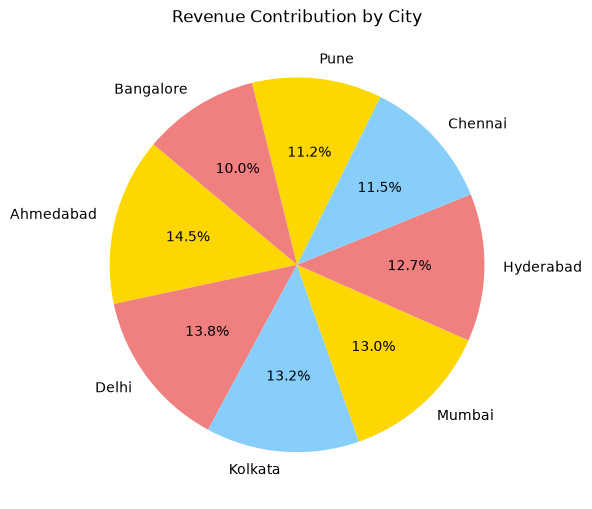

In [108]:
plt.figure(figsize=(6, 6))
city_revenue.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=['gold', 'lightcoral', 'lightskyblue'])
plt.title('Revenue Contribution by City')
plt.ylabel('')  
plt.tight_layout()
plt.show()

##### ...Line Chart

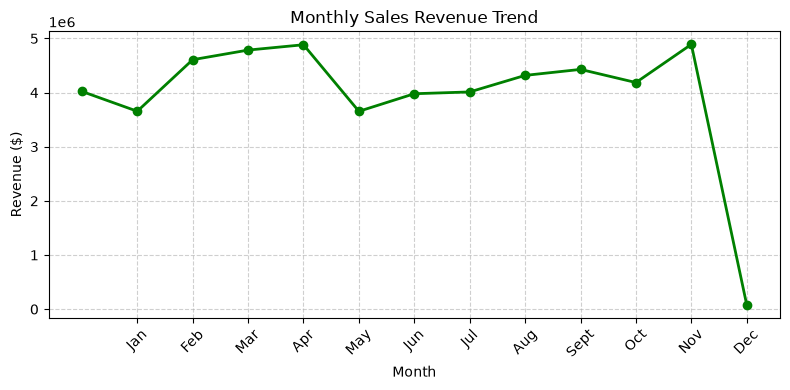

In [111]:
plt.figure(figsize=(8, 4))
monthly_sales_trend.index = monthly_sales_trend.index.astype(str)
monthly_sales_trend.plot(kind='line', marker='o', color='green', linewidth=2)
plt.title('Monthly Sales Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(
    range(1,13),['Jan', 'Feb', 'Mar','Apr','May', 'Jun', 'Jul', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec'],
    rotation=45
)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Part 6 — Academic Business Insights

1. Electronics Unit Velocity: Electronics serve as a core anchor for operational volume, providing consistent cash frequency via everyday consumer tech transactions.
2. High-Ticket Furniture Margins: Furniture pieces exhibit lower aggregate unit counts but capture large absolute transaction figures, cushioning bottom-line margins.
3. Geographic Concentration Risks: Chennai shows structurally distinct top-tier customer transaction values, marking it as a crucial geographic cluster.
4. Data Cleaning Impact: Resolving spelling noise (e.g., mapping Chenai to Chennai) prevents fragmented revenue attribution errors across regional categories.
5. Macro Operational Stability: Evaluation of the time-series curves exhibits steady performance momentum without structural distribution shocks.


### Part 7 — Strategic Recommendations

• Ad-Spend Capital Maximization: Allocate an aggressive subset of ad budgets to top-velocity category anchors to scale current conversions.

• Targeted Regional Interventions: Initiate localized marketing sweeps in low-traction cities to expand active user baselines.

• Counter-Seasonal Promotions: Introduce dynamic calendar-based bundles or flash sales to stabilize systemic monthly trend volatility.